In [1]:
import pandas as pd
import numpy as np

In [2]:
data = pd.read_csv("./data/house_train.csv")
data

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,1456,60,RL,62.0,7917,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,8,2007,WD,Normal,175000
1456,1457,20,RL,85.0,13175,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,MnPrv,NaN,0,2,2010,WD,Normal,210000
1457,1458,70,RL,66.0,9042,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,GdPrv,Shed,2500,5,2010,WD,Normal,266500
1458,1459,20,RL,68.0,9717,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,142125


In [3]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

In [4]:
pd.set_option('display.max_columns', 100)
pd.set_option('display.max_rows', 100)

In [5]:
(data.isna().sum()/len(data)*100).sort_values(ascending=False)

PoolQC           99.520548
MiscFeature      96.301370
Alley            93.767123
Fence            80.753425
MasVnrType       59.726027
FireplaceQu      47.260274
LotFrontage      17.739726
GarageQual        5.547945
GarageFinish      5.547945
GarageYrBlt       5.547945
GarageType        5.547945
GarageCond        5.547945
BsmtExposure      2.602740
BsmtFinType2      2.602740
BsmtFinType1      2.534247
BsmtQual          2.534247
BsmtCond          2.534247
MasVnrArea        0.547945
Electrical        0.068493
1stFlrSF          0.000000
2ndFlrSF          0.000000
LowQualFinSF      0.000000
GrLivArea         0.000000
BsmtFullBath      0.000000
BsmtHalfBath      0.000000
FullBath          0.000000
HalfBath          0.000000
BedroomAbvGr      0.000000
KitchenAbvGr      0.000000
KitchenQual       0.000000
TotRmsAbvGrd      0.000000
Functional        0.000000
Fireplaces        0.000000
CentralAir        0.000000
GarageArea        0.000000
SalePrice         0.000000
Utilities         0.000000
L

In [6]:
data=data.drop(['PoolQC', 'MiscFeature','Alley' ,'Fence','MasVnrType' ,'FireplaceQu'], axis=1)

In [9]:
missing_cols=['LotFrontage', 'GarageQual' , 'GarageFinish' , 'GarageYrBlt' , 'GarageType' , 'GarageCond',
             'BsmtExposure', 'BsmtFinType2', 'BsmtFinType1' , 'BsmtQual', 'BsmtCond', 'MasVnrArea' , 'Electrical']

In [10]:
for col in missing_cols:
    if data[col].dtype=='object':
        data[col]=data[col].fillna(data[col].mode()[0])
    else:
        data[col]=data[col].fillna(data[col].median())

In [11]:
(data.isna().sum()/len(data) * 100).sort_values(ascending=False)

SalePrice        0.0
Id               0.0
MSSubClass       0.0
GarageArea       0.0
GarageQual       0.0
GarageCond       0.0
PavedDrive       0.0
WoodDeckSF       0.0
OpenPorchSF      0.0
EnclosedPorch    0.0
3SsnPorch        0.0
Neighborhood     0.0
Condition1       0.0
Condition2       0.0
BldgType         0.0
HouseStyle       0.0
OverallQual      0.0
OverallCond      0.0
YearBuilt        0.0
YearRemodAdd     0.0
RoofStyle        0.0
RoofMatl         0.0
Exterior1st      0.0
Exterior2nd      0.0
MasVnrArea       0.0
ExterQual        0.0
ExterCond        0.0
Foundation       0.0
BsmtQual         0.0
BsmtCond         0.0
BsmtExposure     0.0
BsmtFinType1     0.0
BsmtFinSF1       0.0
BsmtFinType2     0.0
BsmtFinSF2       0.0
BsmtUnfSF        0.0
TotalBsmtSF      0.0
Heating          0.0
HeatingQC        0.0
CentralAir       0.0
Electrical       0.0
1stFlrSF         0.0
2ndFlrSF         0.0
LowQualFinSF     0.0
GrLivArea        0.0
BsmtFullBath     0.0
BsmtHalfBath     0.0
FullBath     

In [12]:
#!pip install seaborn

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

<Axes: >

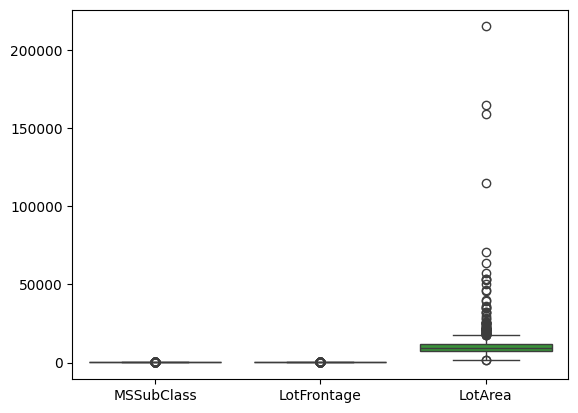

In [14]:
sns.boxplot(data.iloc[:, 1:5])

<Axes: >

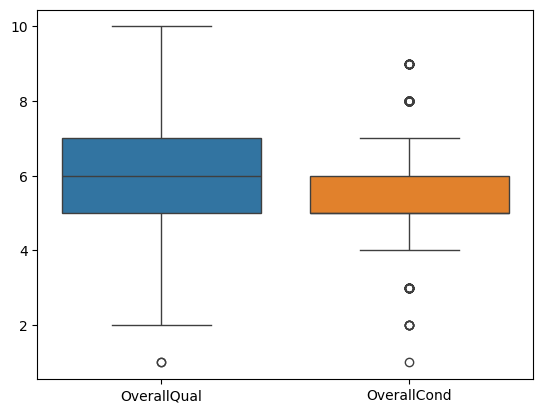

In [15]:
sns.boxplot(data.iloc[:, 16:18])

<Axes: >

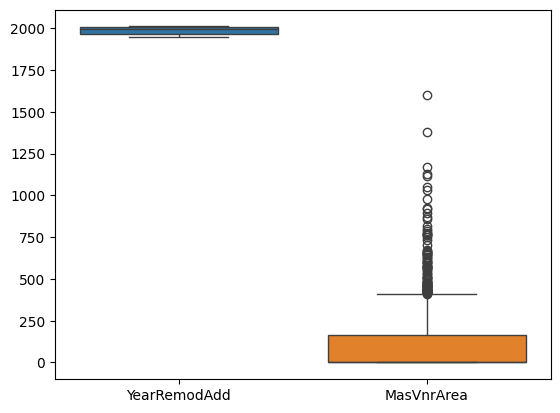

In [16]:
sns.boxplot(data.iloc[:, 19:25])

In [17]:
data2=data.copy()
data3=data.copy()

In [18]:
data.columns

Index(['Id', 'MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street',
       'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope',
       'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle',
       'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'RoofStyle',
       'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrArea', 'ExterQual',
       'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond', 'BsmtExposure',
       'BsmtFinType1', 'BsmtFinSF1', 'BsmtFinType2', 'BsmtFinSF2', 'BsmtUnfSF',
       'TotalBsmtSF', 'Heating', 'HeatingQC', 'CentralAir', 'Electrical',
       '1stFlrSF', '2ndFlrSF', 'LowQualFinSF', 'GrLivArea', 'BsmtFullBath',
       'BsmtHalfBath', 'FullBath', 'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr',
       'KitchenQual', 'TotRmsAbvGrd', 'Functional', 'Fireplaces', 'GarageType',
       'GarageYrBlt', 'GarageFinish', 'GarageCars', 'GarageArea', 'GarageQual',
       'GarageCond', 'PavedDrive', 'WoodDeckSF', 'OpenPorchSF',
       'Enclo

In [19]:
X=data.drop(['SalePrice','Id'], axis=1)
y=data['SalePrice']

In [20]:
X.head(2)

,MSSubClass,MSZoning,LotFrontage,LotArea,Street,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SaleType,SaleCondition
0,60,RL,65.0,8450,Pave,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,196.0,Gd,TA,PConc,Gd,TA,No,GLQ,706,Unf,0,150,856,GasA,Ex,Y,SBrkr,856,854,0,1710,1,0,2,1,3,1,Gd,8,Typ,0,Attchd,2003.0,RFn,2,548,TA,TA,Y,0,61,0,0,0,0,0,2,2008,WD,Normal
1,20,RL,80.0,9600,Pave,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,0.0,TA,TA,CBlock,Gd,TA,Gd,ALQ,978,Unf,0,284,1262,GasA,Ex,Y,SBrkr,1262,0,0,1262,0,1,2,0,3,1,TA,6,Typ,1,Attchd,1976.0,RFn,2,460,TA,TA,Y,298,0,0,0,0,0,0,5,2007,WD,Normal


In [21]:
y

0       208500
1       181500
2       223500
3       140000
4       250000
         ...  
1455    175000
1456    210000
1457    266500
1458    142125
1459    147500
Name: SalePrice, Length: 1460, dtype: int64

In [22]:
X=pd.get_dummies(X)
X.head(2)

,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,TotRmsAbvGrd,Fireplaces,GarageYrBlt,GarageCars,GarageArea,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,MSZoning_C (all),MSZoning_FV,MSZoning_RH,MSZoning_RL,MSZoning_RM,Street_Grvl,Street_Pave,LotShape_IR1,LotShape_IR2,LotShape_IR3,LotShape_Reg,LandContour_Bnk,LandContour_HLS,LandContour_Low,...,Electrical_Mix,Electrical_SBrkr,KitchenQual_Ex,KitchenQual_Fa,KitchenQual_Gd,KitchenQual_TA,Functional_Maj1,Functional_Maj2,Functional_Min1,Functional_Min2,Functional_Mod,Functional_Sev,Functional_Typ,GarageType_2Types,GarageType_Attchd,GarageType_Basment,GarageType_BuiltIn,GarageType_CarPort,GarageType_Detchd,GarageFinish_Fin,GarageFinish_RFn,GarageFinish_Unf,GarageQual_Ex,GarageQual_Fa,GarageQual_Gd,GarageQual_Po,GarageQual_TA,GarageCond_Ex,GarageCond_Fa,GarageCond_Gd,GarageCond_Po,GarageCond_TA,PavedDrive_N,PavedDrive_P,PavedDrive_Y,SaleType_COD,SaleType_CWD,SaleType_Con,SaleType_ConLD,SaleType_ConLI,SaleType_ConLw,SaleType_New,SaleType_Oth,SaleType_WD,SaleCondition_Abnorml,SaleCondition_AdjLand,SaleCondition_Alloca,SaleCondition_Family,SaleCondition_Normal,SaleCondition_Partial
0,60,65.0,8450,7,5,2003,2003,196.0,706,0,150,856,856,854,0,1710,1,0,2,1,3,1,8,0,2003.0,2,548,0,61,0,0,0,0,0,2,2008,False,False,False,True,False,False,True,False,False,False,True,False,False,False,...,False,True,False,False,True,False,False,False,False,False,False,False,True,False,True,False,False,False,False,False,True,False,False,False,False,False,True,False,False,False,False,True,False,False,True,False,False,False,False,False,False,False,False,True,False,False,False,False,True,False
1,20,80.0,9600,6,8,1976,1976,0.0,978,0,284,1262,1262,0,0,1262,0,1,2,0,3,1,6,1,1976.0,2,460,298,0,0,0,0,0,0,5,2007,False,False,False,True,False,False,True,False,False,False,True,False,False,False,...,False,True,False,False,False,True,False,False,False,False,False,False,True,False,True,False,False,False,False,False,True,False,False,False,False,False,True,False,False,False,False,True,False,False,True,False,False,False,False,False,False,False,False,True,False,False,False,False,True,False


In [23]:
X=X.astype('float32')

In [24]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler

In [25]:
X_train, X_valid, y_train, y_valid = train_test_split(X, y, test_size=0.3, random_state=42)

In [26]:
rs=RobustScaler()
rs_X_train=rs.fit_transform(X_train)
rs_X_valid=rs.transform(X_valid)

In [27]:
import joblib
joblib.dump(rs, "./model/iowa_rs.joblib")

['./model/iowa_rs.joblib']

# 출력층 Dense(1)

# model.compile(loss='mean_squared_error', metrics='mse')

In [28]:
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Dense, Input, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.metrics import RootMeanSquaredError

In [29]:
inputs=Input(shape=(rs_X_train.shape[1],))
x=Dense(32, activation='relu')(inputs)
x=Dense(16, activation='relu')(x)
x=Dropout(0.3)(x)
outputs=Dense(1)(x)
base_model=Model(inputs=inputs, outputs=outputs)
base_model.summary()

I0000 00:00:1747976943.561077    2555 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 1347 MB memory:  -> device: 0, name: NVIDIA GeForce MX450, pci bus id: 0000:01:00.0, compute capability: 7.5


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 266)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         8,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,089 (35.50 KB)

 Trainable params: 9,089 (35.50 KB)

 Non-trainable params: 0 (0.00 B)

In [31]:
base_model.compile(loss='mean_squared_error', optimizer='adam', metrics=[RootMeanSquaredError()])
early_stop=EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
model_path="./model/iowa_base-model_best.keras"
check_point=ModelCheckpoint(filepath=model_path, monitor='val_loss', save_best_only=True, verbose=1)
base_model_history=base_model.fit(rs_X_train, y_train, epochs=1000, batch_size=32, validation_data=(rs_X_valid, y_valid),
                                 callbacks=[early_stop, check_point], verbose=1)


Epoch 1/1000


I0000 00:00:1747977353.508159    2911 service.cc:152] XLA service 0x7f4160003ea0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1747977353.508209    2911 service.cc:160]   StreamExecutor device (0): NVIDIA GeForce MX450, Compute Capability 7.5
2025-05-23 14:15:53.553235: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1747977353.732799    2911 cuda_dnn.cc:529] Loaded cuDNN version 90300


13/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 39094116352.0000 - root_mean_squared_error: 197691.0469 

I0000 00:00:1747977355.203608    2911 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - loss: 38750429184.0000 - root_mean_squared_error: 196836.3594
Epoch 1: val_loss improved from inf to 39376629760.00000, saving model to ./model/iowa_base-model_best.keras
32/32 ━━━━━━━━━━━━━━━━━━━━ 4s 57ms/step - loss: 38754738176.0000 - root_mean_squared_error: 196847.7500 - val_loss: 39376629760.0000 - val_root_mean_squared_error: 198435.4531
Epoch 2/1000
21/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 38892240896.0000 - root_mean_squared_error: 197135.1406 
Epoch 2: val_loss improved from 39376629760.00000 to 39364624384.00000, saving model to ./model/iowa_base-model_best.keras
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 38767763456.0000 - root_mean_squared_error: 196845.1562 - val_loss: 39364624384.0000 - val_root_mean_squared_error: 198405.2031
Epoch 3/1000
26/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 40273100800.0000 - root_mean_squared_error: 200659.3750
Epoch 3: val_loss improved from 39364624384.00000 to 39341498368.00000, saving m

...

Epoch 159/1000
24/32 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 2968571392.0000 - root_mean_squared_error: 54435.3711
Epoch 159: val_loss improved from 1717337600.00000 to 1716079488.00000, saving model to ./model/iowa_base-model_best.keras
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 3020287744.0000 - root_mean_squared_error: 54915.2227 - val_loss: 1716079488.0000 - val_root_mean_squared_error: 41425.5898
Epoch 160/1000
24/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 3336017920.0000 - root_mean_squared_error: 57679.6016
Epoch 160: val_loss did not improve from 1716079488.00000
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 3446910976.0000 - root_mean_squared_error: 58632.6445 - val_loss: 1743370624.0000 - val_root_mean_squared_error: 41753.6914
Epoch 161/1000
28/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 3543099648.0000 - root_mean_squared_error: 59360.7500
Epoch 161: val_loss did not improve from 1716079488.00000
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 3490159360.0000 - root_

Epoch 178/1000
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 2805535488.0000 - root_mean_squared_error: 52789.9375
Epoch 178: val_loss improved from 1660947840.00000 to 1640711296.00000, saving model to ./model/iowa_base-model_best.keras
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 2818004736.0000 - root_mean_squared_error: 52908.9961 - val_loss: 1640711296.0000 - val_root_mean_squared_error: 40505.6953
Epoch 179/1000
28/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 3480137728.0000 - root_mean_squared_error: 58818.1328
Epoch 179: val_loss did not improve from 1640711296.00000
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 3455673600.0000 - root_mean_squared_error: 58634.7148 - val_loss: 1671729664.0000 - val_root_mean_squared_error: 40886.7891
Epoch 180/1000
29/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 3133890816.0000 - root_mean_squared_error: 55944.6445
Epoch 180: val_loss did not improve from 1640711296.00000
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 3133449216.0000 - root_

28/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 3355493632.0000 - root_mean_squared_error: 57823.6289
Epoch 197: val_loss did not improve from 1609466368.00000
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 3315048960.0000 - root_mean_squared_error: 57482.3906 - val_loss: 1648745216.0000 - val_root_mean_squared_error: 40604.7422
Epoch 198/1000
26/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 3354631168.0000 - root_mean_squared_error: 57799.6328
Epoch 198: val_loss did not improve from 1609466368.00000
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 3363865600.0000 - root_mean_squared_error: 57903.4062 - val_loss: 1631619968.0000 - val_root_mean_squared_error: 40393.3164
Epoch 199/1000
26/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 5031107072.0000 - root_mean_squared_error: 69740.7812
Epoch 199: val_loss did not improve from 1609466368.00000
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 4664515072.0000 - root_mean_squared_error: 67137.5859 - val_loss: 1612370432.0000 - val_root_mean_square

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 3500967424.0000 - root_mean_squared_error: 58982.5430 - val_loss: 1550582272.0000 - val_root_mean_squared_error: 39377.4336
Epoch 217/1000
27/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 2203787008.0000 - root_mean_squared_error: 46719.1836
Epoch 217: val_loss improved from 1549632512.00000 to 1520788608.00000, saving model to ./model/iowa_base-model_best.keras
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 2323401984.0000 - root_mean_squared_error: 47950.7422 - val_loss: 1520788608.0000 - val_root_mean_squared_error: 38997.2891
Epoch 218/1000
27/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 3282605056.0000 - root_mean_squared_error: 57229.6992
Epoch 218: val_loss improved from 1520788608.00000 to 1517150336.00000, saving model to ./model/iowa_base-model_best.keras
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 3246368256.0000 - root_mean_squared_error: 56919.9922 - val_loss: 1517150336.0000 - val_root_mean_squared_error: 38950.6133
Epoch 21

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 2632810752.0000 - root_mean_squared_error: 51255.9805
Epoch 235: val_loss improved from 1470950144.00000 to 1463706496.00000, saving model to ./model/iowa_base-model_best.keras
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 2633626624.0000 - root_mean_squared_error: 51265.5742 - val_loss: 1463706496.0000 - val_root_mean_squared_error: 38258.4141
Epoch 236/1000
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 2723684352.0000 - root_mean_squared_error: 52140.7148
Epoch 236: val_loss did not improve from 1463706496.00000
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 2729857536.0000 - root_mean_squared_error: 52200.2539 - val_loss: 1473837184.0000 - val_root_mean_squared_error: 38390.5859
Epoch 237/1000
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 2706876416.0000 - root_mean_squared_error: 51956.4375
Epoch 237: val_loss improved from 1463706496.00000 to 1460680192.00000, saving model to ./model/iowa_base-model_best.keras
32/32 ━━━━━━━━━━━━━━

In [ ]:
pred=base_model.predict(rs_X_valid)
pred=pd.DataFrame(pred, columns=['pred'])
pred